In [1]:
%matplotlib widget 
import json
import subprocess
import pandas as pd
import numpy as np

In [2]:
def run(task, workers_count, timeout):
    output_file = '/tmp/test.json'
    command = f'./target/profiling/ruse_benchmarks run --output {output_file} -t {timeout} -b {task} --workers-count {workers_count}'
    sum = 0
    for _ in range(5):
        subprocess.check_call(command, shell=True, stdout=subprocess.DEVNULL)
        with open(output_file, 'r') as fp:
            output = json.load(fp)

        total_time = output['tasks'][0]['total_time']
        delta = pd.Timedelta(seconds=total_time['secs'], nanoseconds=total_time['nanos'])
        sum += delta.total_seconds()

    return sum / 5

In [3]:
TIMEOUT=1000
task = 'benchmarks/tasks/fromDictEnum/benchmarks/mutating/new/ArraySwap.sy'

In [4]:
workers = np.hstack((np.array([1, 2, 4, 8, 10], dtype=np.uint32), np.linspace(16, 256, num=16, dtype=np.uint32)))
print(workers)
data = {'worker_count': [], 'time': []}

for worker_count in workers:
    took = run(task, worker_count, TIMEOUT)
    data['worker_count'].append(worker_count)
    data['time'].append(took)

df = pd.DataFrame(data)

[  1   2   4   8  10  16  32  48  64  80  96 112 128 144 160 176 192 208
 224 240 256]


KeyboardInterrupt: 

In [51]:
df.head()

,chunk_size,worker_count,time
0,1,1,5.638336
1,1,2,3.448739
2,1,4,2.111544
3,1,8,1.545051
4,1,10,1.458501


<Axes: xlabel='worker_count', ylabel='chunk_size'>

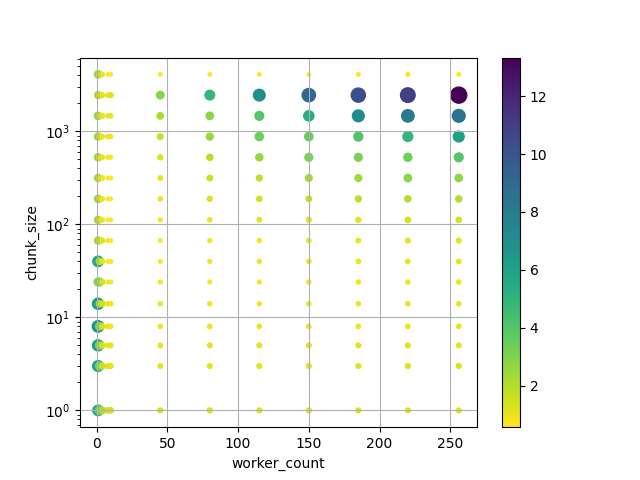

In [52]:
df.plot.line(x='worker_count', y='time', grid=True)